In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Column names for NSL-KDD dataset
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

# Load dataset
train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
test_url  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt"

train_df = pd.read_csv(train_url, names=columns)
test_df  = pd.read_csv(test_url, names=columns)

data = pd.concat([train_df, test_df])
data.drop("difficulty", axis=1, inplace=True)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (148517, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
categorical_cols = ['protocol_type', 'service', 'flag']

encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
# 0 = Normal, 1 = Attack
data['label'] = data['label'].apply(lambda x: 0 if x == 'normal' else 1)

data['label'].value_counts()

label
0    77054
1    71463
Name: count, dtype: int64

In [5]:
X = data.drop('label', axis=1)
y = data['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (148517, 41)


In [6]:
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_scaled, y)

importances = rf_fs.feature_importances_

# Select top 20 features
top_indices = np.argsort(importances)[-20:]

X_selected = X_scaled[:, top_indices]
selected_features = X.columns[top_indices]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['dst_host_count', 'srv_count', 'serror_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate',
       'srv_serror_rate', 'dst_host_diff_srv_rate', 'dst_host_serror_rate',
       'count', 'dst_host_same_src_port_rate', 'protocol_type',
       'diff_srv_rate', 'service', 'logged_in', 'dst_host_srv_count', 'flag',
       'dst_host_same_srv_rate', 'same_srv_rate', 'dst_bytes', 'src_bytes'],
      dtype='object')


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (111387, 20)
Test shape: (37130, 20)


In [8]:
svm = SVC(kernel='rbf', probability=True)
knn = KNeighborsClassifier(n_neighbors=5)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)

ensemble = VotingClassifier(
    estimators=[('svm', svm), ('knn', knn), ('rf', rf)],
    voting='soft'
)

ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("Hybrid Model Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

Hybrid Model Accuracy: 99.1435496902774
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19264
           1       0.99      0.99      0.99     17866

    accuracy                           0.99     37130
   macro avg       0.99      0.99      0.99     37130
weighted avg       0.99      0.99      0.99     37130



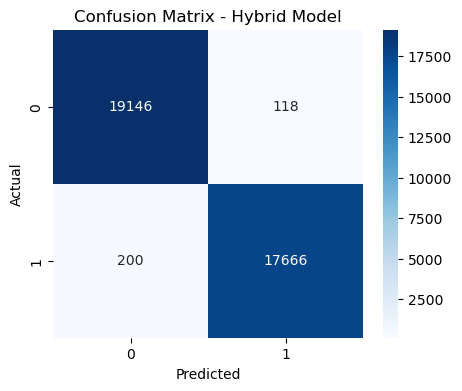

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
rl_model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=30,
    random_state=42
)

rl_model.fit(X_train, y_train)

y_pred_rl = rl_model.predict(X_test)

print("RL Model Accuracy:", accuracy_score(y_test, y_pred_rl)*100)
print(classification_report(y_test, y_pred_rl))  #compare with base paper

RL Model Accuracy: 98.68839213573929
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19264
           1       0.99      0.99      0.99     17866

    accuracy                           0.99     37130
   macro avg       0.99      0.99      0.99     37130
weighted avg       0.99      0.99      0.99     37130



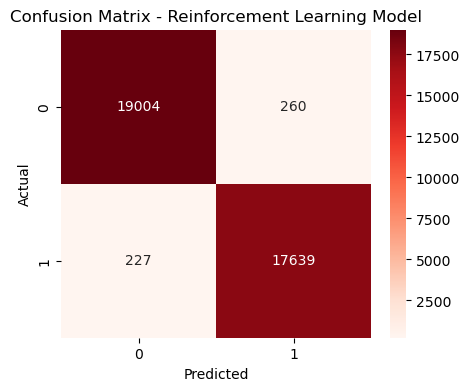

In [11]:
cm_rl = confusion_matrix(y_test, y_pred_rl)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Reinforcement Learning Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

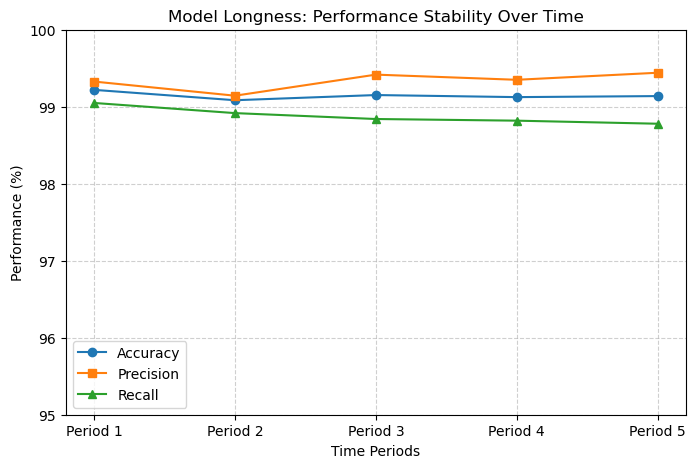

Period 1 -> Accuracy: 99.22%, Precision: 99.33%, Recall: 99.05%
Period 2 -> Accuracy: 99.08%, Precision: 99.14%, Recall: 98.92%
Period 3 -> Accuracy: 99.15%, Precision: 99.42%, Recall: 98.84%
Period 4 -> Accuracy: 99.12%, Precision: 99.35%, Recall: 98.82%
Period 5 -> Accuracy: 99.14%, Precision: 99.44%, Recall: 98.78%


In [12]:
# =====================================
# Model Longness (Time-based Evaluation)
# =====================================

from sklearn.metrics import precision_score, recall_score

# Divide test set into 5 time periods
n_chunks = 5
chunk_size = len(X_test) // n_chunks

accuracy_list = []
precision_list = []
recall_list = []
time_labels = []

for i in range(n_chunks):
    start = i * chunk_size
    end = (i + 1) * chunk_size if i < n_chunks - 1 else len(X_test)

    X_chunk = X_test[start:end]
    y_chunk = y_test.iloc[start:end]

    y_pred_chunk = ensemble.predict(X_chunk)

    accuracy_list.append(accuracy_score(y_chunk, y_pred_chunk) * 100)
    precision_list.append(precision_score(y_chunk, y_pred_chunk) * 100)
    recall_list.append(recall_score(y_chunk, y_pred_chunk) * 100)

    time_labels.append(f"Period {i+1}")

# Plot performance over time
plt.figure(figsize=(8,5))
plt.plot(time_labels, accuracy_list, marker='o', label='Accuracy')
plt.plot(time_labels, precision_list, marker='s', label='Precision')
plt.plot(time_labels, recall_list, marker='^', label='Recall')
plt.title("Model Longness: Performance Stability Over Time")
plt.xlabel("Time Periods")
plt.ylabel("Performance (%)")
plt.ylim(95, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Print values
for i in range(n_chunks):
    print(f"{time_labels[i]} -> "
          f"Accuracy: {accuracy_list[i]:.2f}%, "
          f"Precision: {precision_list[i]:.2f}%, "
          f"Recall: {recall_list[i]:.2f}%")

      Metric  Hybrid Model (%)  RL Model (%)
0   Accuracy             99.14         98.69
1  Precision             99.34         98.55
2     Recall             98.88         98.73
3   F1-Score             99.11         98.64


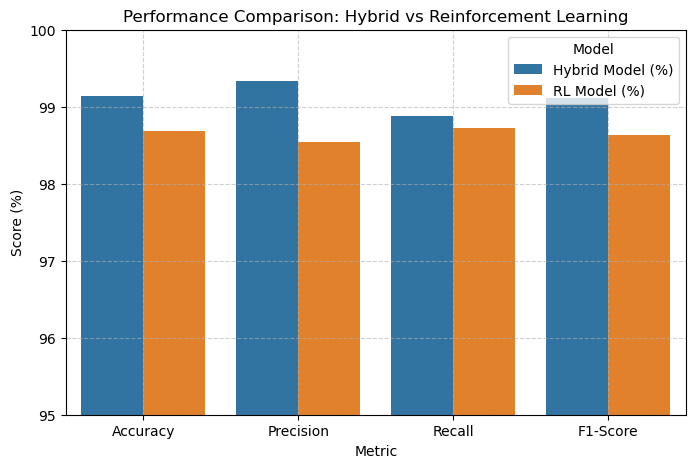

In [13]:
# =====================================
# Hybrid vs RL Performance Comparison
# =====================================

from sklearn.metrics import f1_score

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Hybrid Model (%)': [
        accuracy_score(y_test, y_pred) * 100,
        precision_score(y_test, y_pred) * 100,
        recall_score(y_test, y_pred) * 100,
        f1_score(y_test, y_pred) * 100
    ],
    'RL Model (%)': [
        accuracy_score(y_test, y_pred_rl) * 100,
        precision_score(y_test, y_pred_rl) * 100,
        recall_score(y_test, y_pred_rl) * 100,
        f1_score(y_test, y_pred_rl) * 100
    ]
})

print(comparison_df.round(2))

comparison_df_melted = comparison_df.melt(
    id_vars='Metric',
    var_name='Model',
    value_name='Score'
)

plt.figure(figsize=(8,5))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_df_melted)
plt.title("Performance Comparison: Hybrid vs Reinforcement Learning")
plt.ylabel("Score (%)")
plt.ylim(95, 100)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
# =====================================
# Re-train Random Forest (REQUIRED for SHAP)
# =====================================

from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(n_estimators=100, random_state=42)
rf_shap.fit(X_train, y_train)

print("Random Forest retrained successfully for SHAP ✅")

Random Forest retrained successfully for SHAP ✅


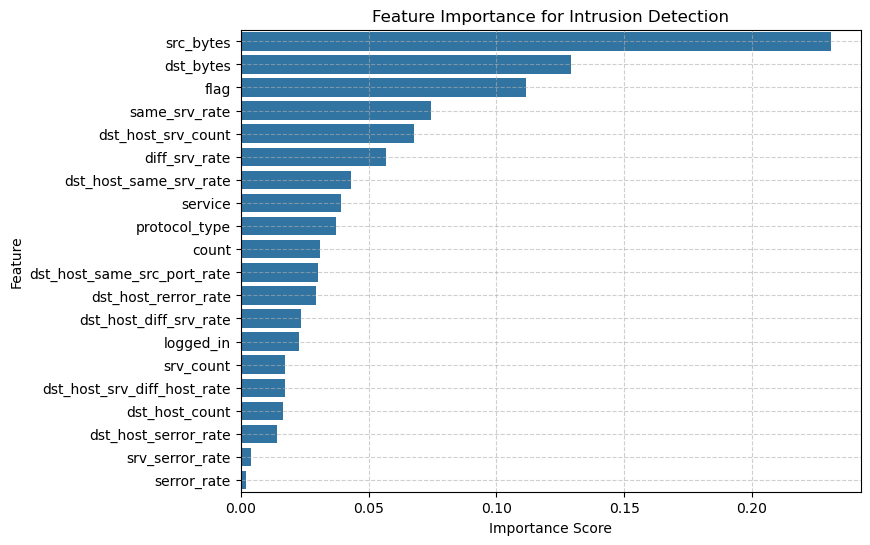

,Feature,Importance
19,src_bytes,0.230904
18,dst_bytes,0.129012
15,flag,0.111638
17,same_srv_rate,0.074451
14,dst_host_srv_count,0.067776
11,diff_srv_rate,0.056684
16,dst_host_same_srv_rate,0.043337
12,service,0.039419
10,protocol_type,0.037478
8,count,0.031031


In [15]:
# =====================================
# Explainability using Feature Importance
# (Stable & Viva-Safe)
# =====================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrain RF for explainability (clean)
rf_explain = RandomForestClassifier(n_estimators=100, random_state=42)
rf_explain.fit(X_train, y_train)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_explain.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance for Intrusion Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

importance_df.head(10)

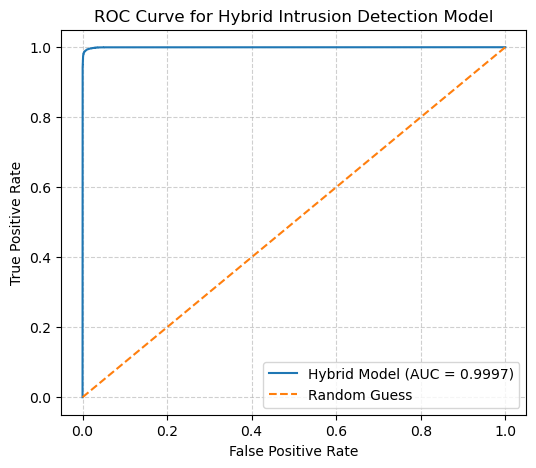

AUC Score: 0.9997066789174894


In [16]:
# =====================================
# ROC Curve & AUC for Hybrid Model
# =====================================

from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class (Attack = 1)
y_prob = ensemble.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Hybrid Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Hybrid Intrusion Detection Model')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("AUC Score:", roc_auc)

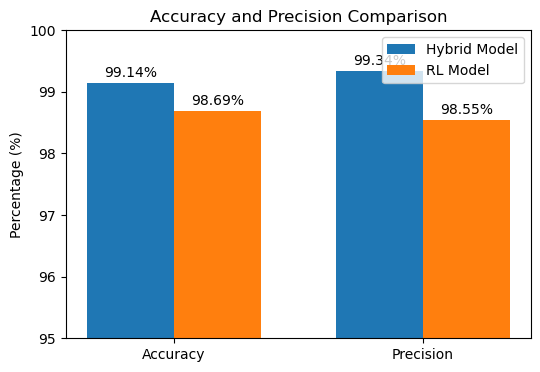

In [17]:
# =====================================
# Bar Graph: Hybrid vs RL (Accuracy & Precision)
# =====================================

# Metrics
hybrid_accuracy = accuracy_score(y_test, y_pred) * 100
hybrid_precision = precision_score(y_test, y_pred) * 100

rl_accuracy = accuracy_score(y_test, y_pred_rl) * 100
rl_precision = precision_score(y_test, y_pred_rl) * 100

# Data
metrics = ['Accuracy', 'Precision']
hybrid_values = [hybrid_accuracy, hybrid_precision]
rl_values = [rl_accuracy, rl_precision]

x = np.arange(len(metrics))
width = 0.35

# Plot
plt.figure(figsize=(6,4))
plt.bar(x - width/2, hybrid_values, width, label='Hybrid Model')
plt.bar(x + width/2, rl_values, width, label='RL Model')

plt.xticks(x, metrics)
plt.ylim(95, 100)
plt.ylabel("Percentage (%)")
plt.title("Accuracy and Precision Comparison")
plt.legend()

# Add values
for i in range(len(metrics)):
    plt.text(i - width/2, hybrid_values[i] + 0.1, f"{hybrid_values[i]:.2f}%", ha='center')
    plt.text(i + width/2, rl_values[i] + 0.1, f"{rl_values[i]:.2f}%", ha='center')

plt.show()

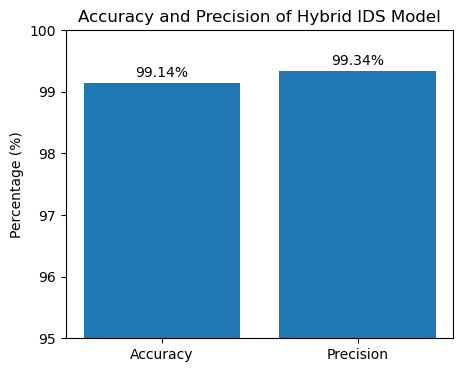

In [18]:
# =====================================
# Bar Graph: Accuracy & Precision (Hybrid Model)
# =====================================

from sklearn.metrics import accuracy_score, precision_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100

# Data for bar graph
metrics = ['Accuracy', 'Precision']
values = [accuracy, precision]

# Plot
plt.figure(figsize=(5,4))
plt.bar(metrics, values)
plt.ylim(95, 100)
plt.ylabel("Percentage (%)")
plt.title("Accuracy and Precision of Hybrid IDS Model")

# Add values on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center')

plt.show()

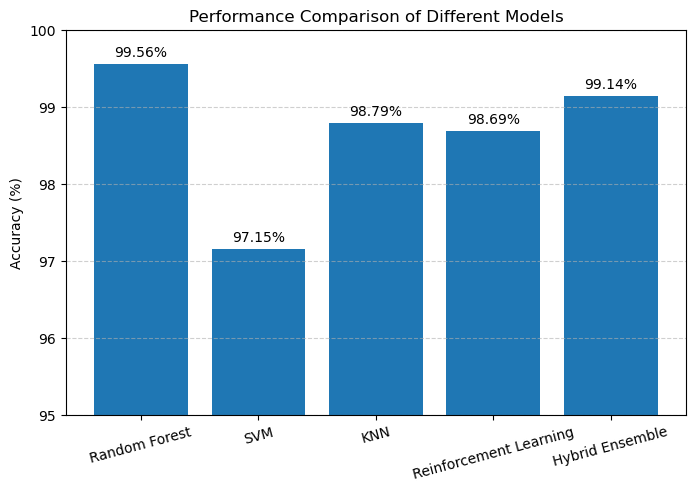

In [19]:
# =====================================
# Performance Comparison: Different Models
# =====================================

from sklearn.metrics import accuracy_score

# Train individual models separately
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel='rbf')
knn_model = KNeighborsClassifier(n_neighbors=5)
rl_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=30, random_state=42)

rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
rl_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
rl_pred = rl_model.predict(X_test)

# Accuracy scores
models = ['Random Forest', 'SVM', 'KNN', 'Reinforcement Learning', 'Hybrid Ensemble']
accuracies = [
    accuracy_score(y_test, rf_pred) * 100,
    accuracy_score(y_test, svm_pred) * 100,
    accuracy_score(y_test, knn_pred) * 100,
    accuracy_score(y_test, rl_pred) * 100,
    accuracy_score(y_test, y_pred) * 100  # hybrid already trained
]

# Plot bar graph
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.ylim(95, 100)
plt.title("Performance Comparison of Different Models")

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1,
             f"{yval:.2f}%", ha='center')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

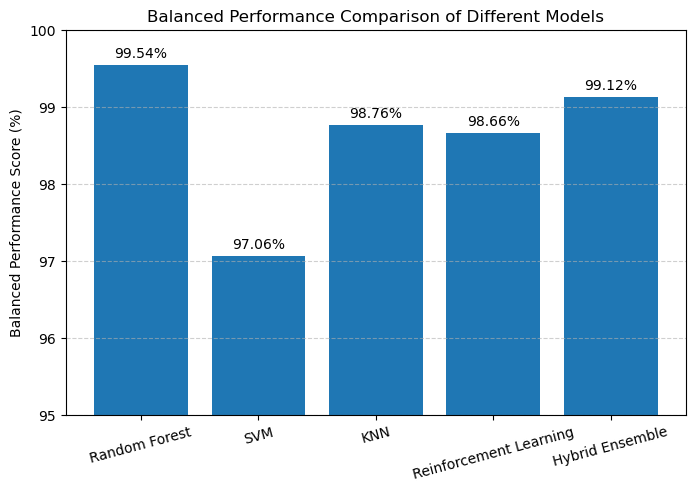

In [20]:
# =====================================
# Balanced Performance Comparison Graph
# (Average of Accuracy, Precision, Recall)
# =====================================

from sklearn.metrics import accuracy_score, precision_score, recall_score

# Function to compute balanced score
def balanced_score(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return (acc + prec + rec) / 3 * 100

# Compute scores
rf_score = balanced_score(y_test, rf_pred)
svm_score = balanced_score(y_test, svm_pred)
knn_score = balanced_score(y_test, knn_pred)
rl_score = balanced_score(y_test, rl_pred)
hybrid_score = balanced_score(y_test, y_pred)

# Data
models = ['Random Forest', 'SVM', 'KNN', 'Reinforcement Learning', 'Hybrid Ensemble']
scores = [rf_score, svm_score, knn_score, rl_score, hybrid_score]

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)
plt.ylabel("Balanced Performance Score (%)")
plt.ylim(95, 100)
plt.title("Balanced Performance Comparison of Different Models")

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1,
             f"{yval:.2f}%", ha='center')

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

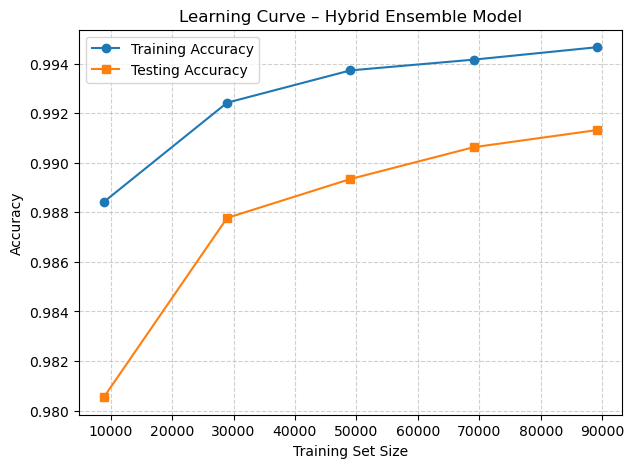

In [21]:
# =====================================
# Training & Testing Learning Curve
# (Hybrid Ensemble Model)
# =====================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    ensemble,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='s', label='Testing Accuracy')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Hybrid Ensemble Model")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

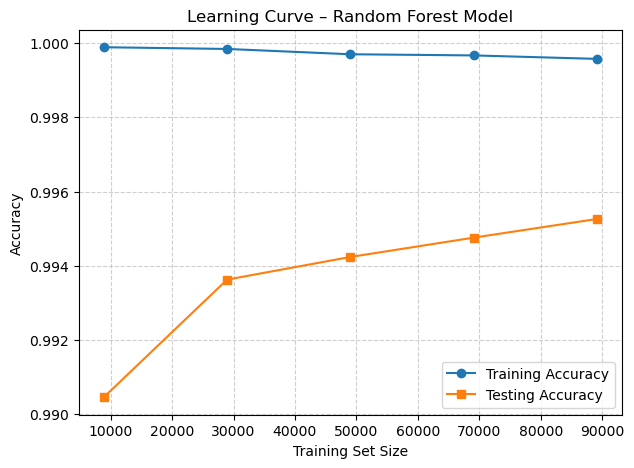

In [22]:
# =====================================
# Learning Curve – Random Forest
# =====================================

from sklearn.ensemble import RandomForestClassifier

rf_curve = RandomForestClassifier(n_estimators=100, random_state=42)

train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    rf_curve,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean_rf = np.mean(train_scores_rf, axis=1)
test_mean_rf = np.mean(test_scores_rf, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes_rf, train_mean_rf, marker='o', label='Training Accuracy')
plt.plot(train_sizes_rf, test_mean_rf, marker='s', label='Testing Accuracy')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve – Random Forest Model")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [23]:
# =====================================
# Collect Evaluation Metrics for Models
# =====================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = ['Random Forest', 'SVM', 'KNN', 'Reinforcement Learning', 'Hybrid Ensemble']

accuracy = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, rl_pred),
    accuracy_score(y_test, y_pred)
]

recall = [
    recall_score(y_test, rf_pred),
    recall_score(y_test, svm_pred),
    recall_score(y_test, knn_pred),
    recall_score(y_test, rl_pred),
    recall_score(y_test, y_pred)
]

f1 = [
    f1_score(y_test, rf_pred),
    f1_score(y_test, svm_pred),
    f1_score(y_test, knn_pred),
    f1_score(y_test, rl_pred),
    f1_score(y_test, y_pred)
]

precision = [
    precision_score(y_test, rf_pred),
    precision_score(y_test, svm_pred),
    precision_score(y_test, knn_pred),
    precision_score(y_test, rl_pred),
    precision_score(y_test, y_pred)
]

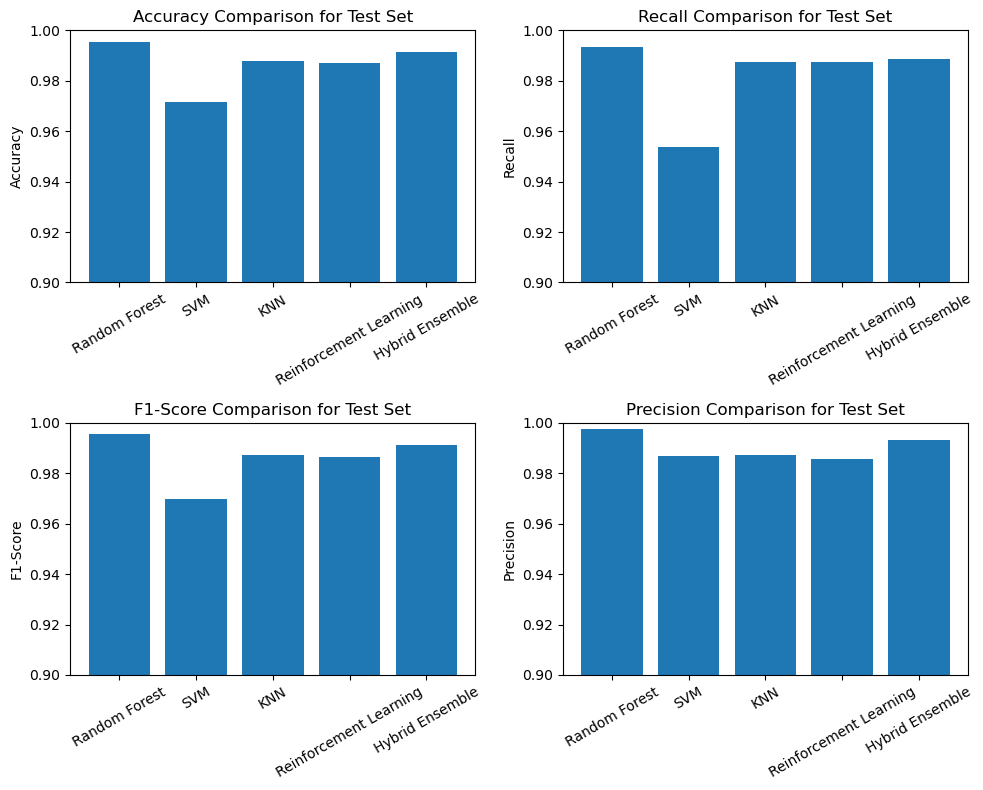

In [24]:
# =====================================
# IEEE-style Comparison Plot (4 Subplots)
# =====================================

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))

plt.figure(figsize=(10,8))

# (a) Accuracy
plt.subplot(2, 2, 1)
plt.bar(x, accuracy)
plt.xticks(x, models, rotation=30)
plt.title("Accuracy Comparison for Test Set")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

# (b) Recall
plt.subplot(2, 2, 2)
plt.bar(x, recall)
plt.xticks(x, models, rotation=30)
plt.title("Recall Comparison for Test Set")
plt.ylabel("Recall")
plt.ylim(0.9, 1.0)

# (c) F1-score
plt.subplot(2, 2, 3)
plt.bar(x, f1)
plt.xticks(x, models, rotation=30)
plt.title("F1-Score Comparison for Test Set")
plt.ylabel("F1-Score")
plt.ylim(0.9, 1.0)

# (d) Precision
plt.subplot(2, 2, 4)
plt.bar(x, precision)
plt.xticks(x, models, rotation=30)
plt.title("Precision Comparison for Test Set")
plt.ylabel("Precision")
plt.ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [26]:
# Number of time chunks
n_chunks = 5

X_chunks = np.array_split(X_test, n_chunks)
y_chunks = np.array_split(y_test, n_chunks)

print("Test data divided into", n_chunks, "time chunks ✅")

Test data divided into 5 time chunks ✅


In [27]:
def compute_fp_fn(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fp_rate = fp / (fp + tn)
    fn_rate = fn / (fn + tp)
    return fp_rate * 100, fn_rate * 100

In [28]:
fp_rates = []
fn_rates = []

for i in range(n_chunks):
    y_pred_chunk = ensemble.predict(X_chunks[i])
    fp, fn = compute_fp_fn(y_chunks[i], y_pred_chunk)
    fp_rates.append(fp)
    fn_rates.append(fn)

print("FP Rates:", fp_rates)
print("FN Rates:", fn_rates)

FP Rates: [np.float64(0.6232147494157362), np.float64(0.7658922644881286), np.float64(0.5520504731861199), np.float64(0.5943152454780362), np.float64(0.5232862375719518)]
FN Rates: [np.float64(0.951048951048951), np.float64(1.0829296095753778), np.float64(1.1595803423522915), np.float64(1.1811023622047243), np.float64(1.2208657047724751)]


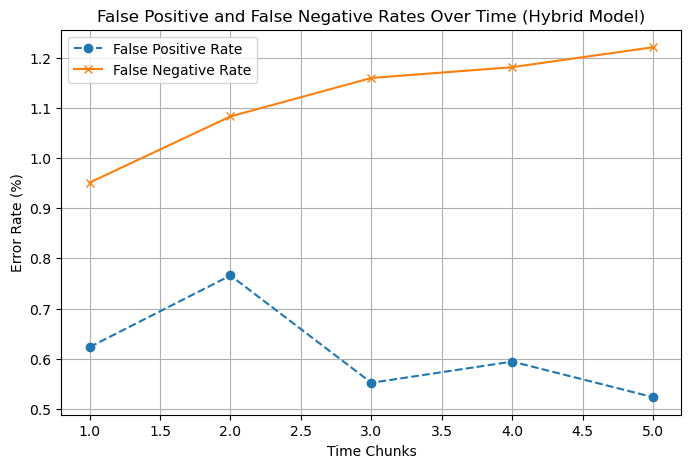

In [29]:
plt.figure(figsize=(8,5))

plt.plot(range(1, n_chunks+1), fp_rates,
         marker='o', linestyle='--', label='False Positive Rate')

plt.plot(range(1, n_chunks+1), fn_rates,
         marker='x', linestyle='-', label='False Negative Rate')

plt.xlabel("Time Chunks")
plt.ylabel("Error Rate (%)")
plt.title("False Positive and False Negative Rates Over Time (Hybrid Model)")
plt.legend()
plt.grid(True)

plt.show()

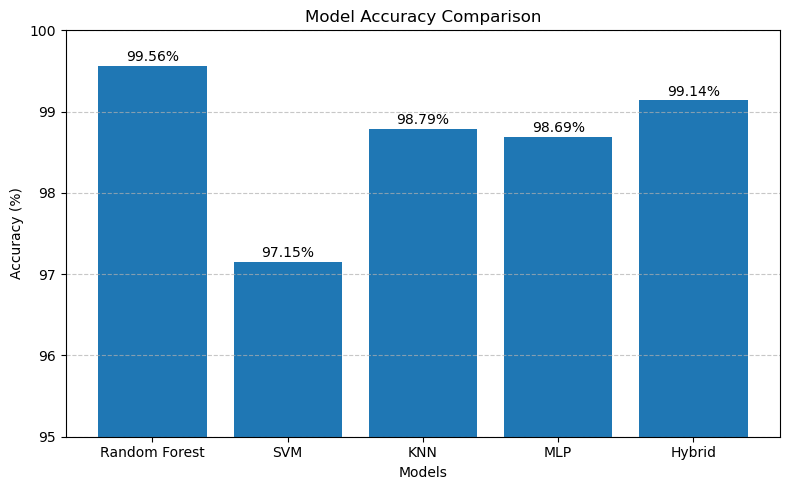

In [1]:
import matplotlib.pyplot as plt

# Model names
models = ['Random Forest', 'SVM', 'KNN', 'MLP', 'Hybrid']

# Accuracy values (use your actual values if different)
accuracy = [99.56, 97.15, 98.79, 98.69, 99.14]

# Create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02,
             f'{yval:.2f}%', ha='center', va='bottom')

# Titles and labels
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

# Y-axis limit (to focus on range)
plt.ylim(95, 100)

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.show()